In [251]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

def clean_mathematica_number(s):
    return float(s[:-4])  # Remove first char and last 3 chars (`10)



def abs_sq(q):
    return np.sum(q**2, axis=-1)

def dot(q1, q2):
    return np.sum(q1*q2, axis=-1)

def get_F(exp_file, coeff_file, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2):
    F_exps_mathematica = np.array(pd.read_csv(exp_file, names=["k12", "k22", "k32", "q2", "k1mq2", "k2pq2", "k3mq2"]))
    F_coeffs_mathematica = np.array(pd.read_csv(coeff_file, names = ["coeff"]))

    coeffs = F_coeffs_mathematica[:,0]
    exp_k12 = F_exps_mathematica[:,0]
    exp_k22 = F_exps_mathematica[:,1]
    exp_k32 = F_exps_mathematica[:,2]
    exp_q2 = F_exps_mathematica[:,3]
    exp_k1mq2 = F_exps_mathematica[:,4]
    exp_k2pq2 = F_exps_mathematica[:,5]
    exp_k3mq2 = F_exps_mathematica[:,6]


    F = 0
    for i in range(len(coeffs)):
        F += clean_mathematica_number(coeffs[i]) * k12**exp_k12[i] * k22**exp_k22[i] * k32**exp_k32[i] * q2**exp_q2[i] * k1mq2**exp_k1mq2[i] * k2pq2**exp_k2pq2[i] * k3mq2**exp_k3mq2[i]

    return F

def compare(x, y1, y2, label_y1, label_y2, ylabel):
    res = 1 - y1/y2

    print("factor = ",np.mean(y1/y2))

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.2)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, y1, label=label_y1)
    ax1.plot(x, y2, label=label_y2)
    ax1.set_ylabel(rf"${ylabel}$")
    ax1.legend()
    ax1.grid()

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x, res, color='black', label="Residuals")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.set_xscale("log")
    ax2.grid()

In [252]:
h = 2/3
k_size = 500
k_min = 1e-3*h
k_max = 1.*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)

k1_vec = np.zeros((k_size, 3))
k2_vec = np.zeros((k_size, 3))
q_vec = np.zeros((k_size, 3))

k1_vec[:, 0] = k/10.
k1_vec[:, 1] = -k/10.
k2_vec[:, 0] = -k*40
k2_vec[:, 1] = k**2
k2_vec[:, 2] = -np.sqrt(k)/13.
k3_vec = -k1_vec -k2_vec
q_vec[:, 0] = -k/3.
q_vec[:, 1] = k**1.5*17.
q_vec[:, 2] = np.sqrt(k)/3.

k12 = abs_sq(k1_vec)
k22 = abs_sq(k2_vec)
k32 = abs_sq(- k1_vec - k2_vec)
q2  = abs_sq(q_vec)
k1mq2  = abs_sq(k1_vec - q_vec)
k2pq2  = abs_sq(k2_vec + q_vec)
k3mq2  = abs_sq(k3_vec - q_vec)

# $F_2$

In [253]:
def F2(q1, q2):
    terms = 10 + 3* abs_sq(q1+q2)/abs_sq(q1) + 3* abs_sq(q1+q2)/abs_sq(q2) - 5* abs_sq(q1)/abs_sq(q2) - 5* abs_sq(q2)/abs_sq(q1) + 2* abs_sq(q1+q2)**2/( abs_sq(q1)*abs_sq(q2))
    return terms/28




# $F_3$

factor =  1.0
factor =  1.0000000000000417
factor =  1.0000000000000417


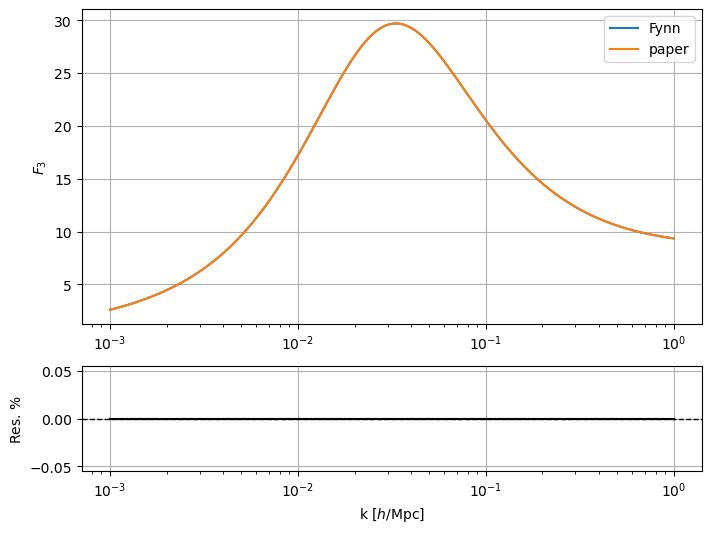

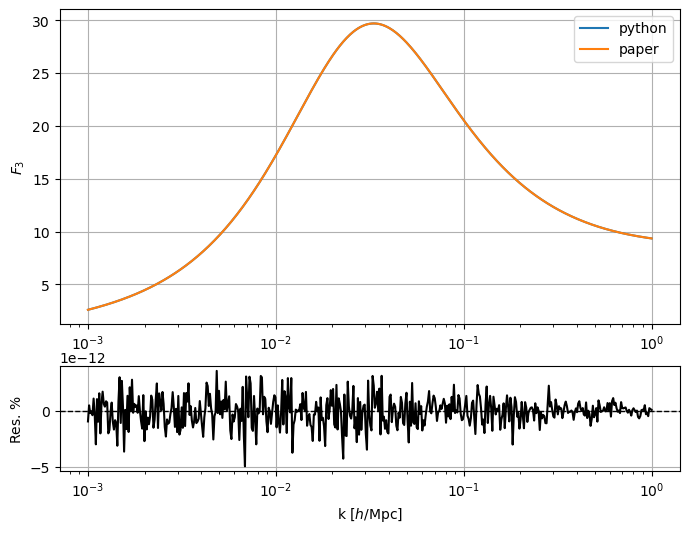

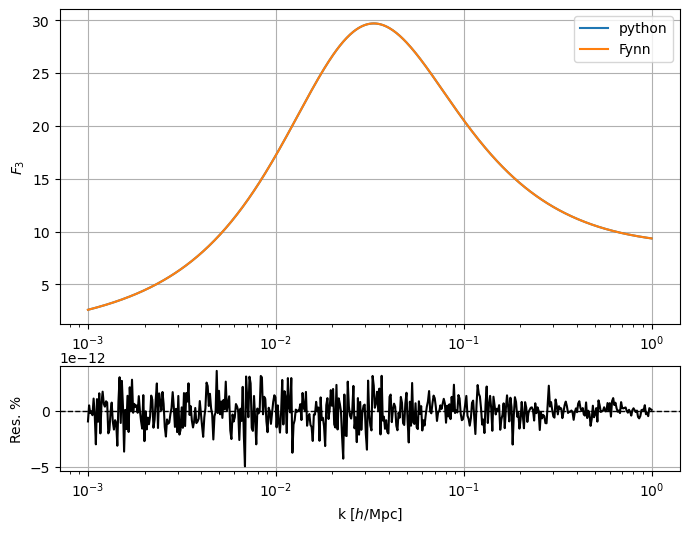

In [254]:
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica/0 kernels"

def F3(q1, q2, q3):
    q12 = dot(q1, q1)
    q22 = dot(q2, q2)
    q32 = dot(q3, q3)
    q1q2 = dot(q1, q2)
    q2q3 = dot(q2, q3)
    q3q1 = dot(q3, q1)
    line1 = ( q1q2 * abs_sq(q1+q2)/21. + q22*dot(q1, q1+q2)/14. ) / (3.*q12*q22*q32 * abs_sq(q1+q2))
    line2 = 7.*q32* dot(q1+q2,q1+q2+q3) + dot(q3, q1+q2) * abs_sq(q1+q2+q3)
    line3 = (dot(q1, q2+q3)*abs_sq(q1+q2+q3))/(3.*q12*q22*q32 * abs_sq(q2+q3)) * (q2q3*abs_sq(q2+q3)/21. + q32*dot(q2, q2+q3)/14.)
    line4 = dot(q1, q1+q2+q3)/(18*q12*q22*q32) * (q2q3 * abs_sq(q2+q3) + 5.*q32 * dot(q2, q2+q3))
    return line1*line2 + line3 + line4

def F3s(q1, q2, q3):
    return (F3(q1, q2, q3) + F3(q1, q3, q2) + F3(q2, q1, q3) + F3(q2, q3, q1) + F3(q3, q1, q2) + F3(q3, q2, q1))/6.

exp_file_1      = dir + "/f3simple1_real_exps.csv"
coeff_file_1    = dir + "/f3simple1_real_coeffs.csv"

exp_file_2      = dir + "/f3simple2_real_exps.csv"
coeff_file_2    = dir + "/f3simple2_real_coeffs.csv"


F3_1 = get_F(exp_file_1, coeff_file_1, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)
F3_2 = get_F(exp_file_2, coeff_file_2, k12, k22, k32, q2, k1mq2, k2pq2, k3mq2)
F3_3 = F3(q_vec, -k2_vec - q_vec, -k1_vec)

compare(k/h, F3_1, F3_2, "Fynn", "paper", "F_3")
compare(k/h, F3_3, F3_2, "python", "paper", "F_3")
compare(k/h, F3_3, F3_1, "python", "Fynn", "F_3")

